## 1. LOAD REQUIRES LIBRARIES

In [46]:
import importlib.util
import subprocess
import sys

# List of required packages
packages = [
    "pandas", "scipy", "sklearn", "matplotlib", "numpy", "adjustText",
    "seaborn", "kneed", "tabulate", "matplotlib-venn", "umap-learn",
]

# Function to check and install packages
def check_install(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    else:
        print(f"{package} is already installed.")

# Check and install missing packages
for package in packages:
    check_install(package)

pandas is already installed.
scipy is already installed.
sklearn is already installed.
matplotlib is already installed.
numpy is already installed.
Installing adjustText...
seaborn is already installed.
kneed is already installed.
tabulate is already installed.
Installing matplotlib-venn...
Installing umap-learn...


In [47]:
import pandas as pd
from sklearn.preprocessing import scale, StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
from sklearn.manifold import TSNE
from kneed import KneeLocator
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, inconsistent
import matplotlib.patches as mpatches
from tabulate import tabulate
from difflib import get_close_matches
from matplotlib.lines import Line2D
from matplotlib_venn import venn2
import textwrap
import umap.umap_ as umap
from adjustText import adjust_text


## 2. Clustering gene expression data in healthy tissues

<div style="text-align: justify; color: #aaa7a7">
The aim of the exercise is to find out if the samples belonging to different tissues in different species cluster together by species or by tissue. To answer this:

-   Download the [data](https://www.ebi.ac.uk/biostudies/arrayexpress/studies/E-MTAB-6081) (design and tpm files) corresponding to the publication [An RNASeq normal tissue atlas for mouse and rat](https://www.nature.com/articles/sdata2017185).
-   Download the [gene expression data](https://storage.googleapis.com/adult-gtex/bulk-gex/v10/rna-seq/GTEx_Analysis_v10_RNASeQCv2.4.2_gene_median_tpm.gct.gz) corresponding to the publication [The Genotype-Tissue Expression (GTEx) pilot analysis: multitissue gene regulation in humans](https://www.science.org/doi/10.1126/science.1262110) from the [GTEX portal](https://gtexportal.org/home/datasets)

From the three datasets, keep only tissues belonging to the following categories:
</div>

In [3]:
tissues = ["brain", "colon", "duodenum", "esophagus", "heart", "ileum", "jejunum", "kidney",  "liver", 
           "pancreas", "quadriceps",  "stomach", "thymus"]

### 2.1. Load Data

<div style="text-align: justify;">
After loading the data, the set_index('Name') function modifies the human_data DataFrame by setting the "Name" column as the index, making gene names the row labels instead of a regular column.  
</div>

In [5]:
human_data = pd.read_csv("data/human.gct", sep="\t", skiprows=2, )
human_data = human_data.set_index('Name')
mouse_data = pd.read_csv("data/mouse.txt",sep="\t")
rat_data = pd.read_csv("data/rat.txt",sep="\t")
species_ids = pd.read_csv("data/species.txt", sep=",")

### 2.2. Data Preparation

#### 2.2.1. Filtering Data Based on Tissue Names
<div style="text-align: justify;">
First, we filtered human, rat and mouse datasets by keeping only the columns related to specific tissues listed in the tissues list. If a column does not contain a tissue name (determined by splitting the column name at underscores and converting it to lowercase for case-insensitive comparison), it is dropped from the dataset.
 
</div>

In [6]:
tissues.append("gene_symbol_human")

for i in human_data:
  if not any(tissue in i.lower().split('_') for tissue in tissues): 
               human_data.drop(columns=[i], inplace = True)

<div style="text-align: justify;">
To achieve this in the case of mouse and rat datasets, we first convert all tissue names in tissues to lowercase for case-insensitive comparision. Since some tissue names may appear in different forms (e.g., singular vs. plural), we used the get_close_matches() function to find the best match between the extracted tissue name (from column headers) and those in the tissues list.  
</div>

In [7]:
# Convert tissue list to lowercase for case-insensitive comparison
tissues = [t.lower() for t in tissues]

# Function to match extracted tissue names to known tissues
def get_best_match(tissue_name, tissue_list):
    match = get_close_matches(tissue_name, tissue_list, n=1, cutoff=0.8) 
    return match[0] if match else None

### FILTERING RAT DATA ###

# Store columns to drop
cols_to_drop = []

# Check extracted tissue names
for col in rat_data.columns:
    tissue_name = col.lower().split('_')[-1]  
    
    # Find the best match in the tissue list
    best_match = get_best_match(tissue_name, tissues)
    
    if not best_match:  
        cols_to_drop.append(col)

# Drop the unwanted columns
rat_data.drop(columns=cols_to_drop, inplace=True)

### FILTERING MOUSE DATA ###

cols_to_drop = []

for col in mouse_data.columns:
    tissue_name = col.lower().split('_')[-1]  
    
    best_match = get_best_match(tissue_name, tissues)
    
    if not best_match: 
        cols_to_drop.append(col)

mouse_data.drop(columns=cols_to_drop, inplace=True)

#### 2.2.2. Appending Species Lables to Column Names

<div style="text-align: justify;">
We modified the column names of the three datases by appending species-specific labels. This transformation ensures that column names remain distinct when merging.
</div>

In [8]:
mouse_index = mouse_data.index
mouse_data.columns = [col + "-mouse" for col in mouse_data.columns]
mouse_data.index = mouse_index

In [9]:
rat_index = rat_data.index
rat_data.columns = [col + "-rat" for col in rat_data.columns]
rat_data.index = rat_index

In [10]:
human_index = human_data.index
human_data.columns = [col + "-human" for col in human_data.columns]
human_data.index = human_index

#### 2.2.3. Removing Duplicates

<div style="text-align: justify;">
We removed any duplicate rows from the human, mouse, and rat datasets. This ensures that redundant gene expression profiles do not skew downstrem analyses.
</div>

In [11]:
human_data.drop_duplicates(inplace=True)
print(f"Number of duplicate gene expression profiles in human data: {human_data.T.duplicated().sum()}")

mouse_data.drop_duplicates(inplace=True)
print(f"Number of duplicate gene expression profiles in mouse data: {mouse_data.T.duplicated().sum()}")

rat_data.drop_duplicates(inplace=True)
print(f"Number of duplicate gene expression profiles in rat data: {rat_data.T.duplicated().sum()}")

Number of duplicate gene expression profiles in human data: 0
Number of duplicate gene expression profiles in mouse data: 0
Number of duplicate gene expression profiles in rat data: 0


#### 2.2.4. Printing Dataset Shapes

<div style="text-align: justify;">
We checked the shape of the datasets. The output shows the dimension of each dataset, where the first number represents the number of genes (rows) and the second number represents the number of tissues (columns)
</div>

In [12]:
print(human_data.shape)
print(mouse_data.shape)
print(rat_data.shape)

(43220, 40)
(34640, 39)
(23921, 39)


### 2.3. Cross-Species Gene Expression Integration and Preprocessing

<div style="text-align: justify;">
 The species_ids file represents a mapping of known homologous genes across human, mouse, and rat. It acts as a reference table that links equivalent genes in these species, allowing for comparative analysis of gene expression.
 

It was created using Ensembl BioMart, and retrieving the Gene stable ID from Rat and Mouse genes, looking in the Human database, which provides homologous gene mappings based on the ability to map known mouse and rat genes to its human homologous.
</div>

In [13]:
species_ids

,Rat gene stable ID,Gene stable ID version,Mouse gene stable ID
0,NaN,ENSG00000210049.1,NaN
1,NaN,ENSG00000211459.2,NaN
2,NaN,ENSG00000210077.1,NaN
3,NaN,ENSG00000210082.2,NaN
4,NaN,ENSG00000209082.1,NaN
...,...,...,...
141222,ENSRNOG00000004524,ENSG00000121644.19,ENSMUSG00000026502
141223,NaN,ENSG00000278757.1,ENSMUSG00000119731
141224,NaN,ENSG00000206692.1,NaN
141225,ENSRNOG00000013865,ENSG00000163867.17,ENSMUSG00000042408


#### 2.3.1. Cleaning and Organizing species_ids
<div style="text-align: justify;">
We first removed missing values and standardized column names to ensure consistency across species. The columns were reordered so that human gene symbols appear first, making it easier to merge datasets later.
</div>

In [14]:
species_ids = species_ids.dropna()
species_ids.columns = ["gene_symbol_rat", "gene_symbol_human", "gene_symbol_mouse"]
species_ids = species_ids[["gene_symbol_human", "gene_symbol_mouse", "gene_symbol_rat"]]

#### 2.3.2. Resetting Indexes and Renaming Columns
<div style="text-align: justify;">
Since gene symbols were originally stored as index values in each species dataset, we reset the index and explicitly assigned meaningful column names. This was necessary for merging datasets correctly based on gene symbols. 
</div>

In [15]:
human_data = human_data.reset_index().rename(columns={'Name':"gene_symbol_human"})
mouse_data = mouse_data.reset_index().rename(columns={'index': 'gene_symbol_mouse'})
rat_data = rat_data.reset_index().rename(columns={'index': 'gene_symbol_rat'})

#### 2.3.3. Merging Data Across Species
<div style="text-align: justify;">
The datasets were merged using left joins to integrate human, rat, and mouse gene expression data while keeping all genes present in species_ids. This ensures that only genes with mapped homologs across species are retained. 
</div>

In [16]:
result = pd.merge(species_ids, human_data, on='gene_symbol_human', how='left')
result = pd.merge(result, rat_data, on='gene_symbol_rat', how='left')
result = pd.merge(result, mouse_data, on='gene_symbol_mouse', how='left')

#### 2.3.4. Data Cleaning and Transformation
<div style="text-align: justify;">
After merging, we removed any rows with missing values (NaN) to ensure that only complete cases were kept. Next, we set the 'gene_symbol_human' column as the index and drop the corresponding 'gene_symbol_mouse' and 'gene_symbol_rat' columns, as they are not needed for further analysis. To normalize the data and handle potential zeros, we apply a log transformation using np.log1p, which computes log(1 + x) to avoid issues with undefined logarithms.
</div>

In [17]:
# Drop rows with NaN values
result.dropna(how='any', inplace=True)

# Set index and drop species columns
result = result.set_index('gene_symbol_human').drop(columns=['gene_symbol_mouse', 'gene_symbol_rat'])

# Apply log transformation (use log1p to avoid issues with zeros)
result = np.log1p(result)

# Restore index
result.index = result.index

In [18]:
result.drop_duplicates(inplace=True)
result = result.T

<div style="text-align: justify;">
After merging the three datasets, 118 tissues (rows) and 17331 genes (columns) were selected.
</div>

In [19]:
print(result.shape)

(118, 17331)


### 2.4. K-MEANS

#### 2.4.1. Elbow Test
<div style="text-align: justify;">
To determine the optimal number of clusters, we first implemented the Elbow Method. The methods relies on computing the Within-Cluster Sum of Square (WCSS) for a a range of cluster values. The optimal k is detected using KneeLocator, which identifes the "elbow" point where adding more clusters no longer significantly reduce WCSS.
</div>

Optimal number of clusters (Elbow Method): 4


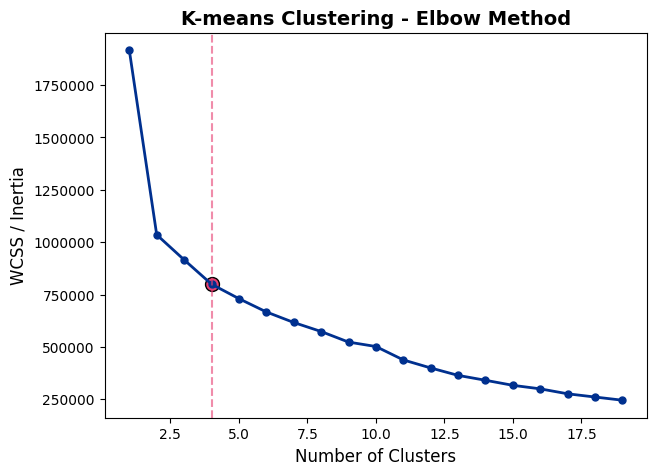

In [20]:
# Ensure reproducibility
random_state = 42

# Compute WCSS values
wcss = []
for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=random_state, n_init=10)  
    kmeans.fit(result)
    wcss.append(kmeans.inertia_)

# Automatically detect the elbow point
kneedle = KneeLocator(range(1, 20), wcss, curve="convex", direction="decreasing")
optimal_k = kneedle.elbow 

print(f"Optimal number of clusters (Elbow Method): {optimal_k}")

# Plot the WCSS values
plt.figure(figsize=(7,5))  
plt.plot(range(1, 20), wcss, marker='o', linestyle='-', markersize=5, linewidth=2, color='#00308F')  
plt.title('K-means Clustering - Elbow Method', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('WCSS / Inertia', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.axvline(x=optimal_k, linestyle="--", color="#e64072", alpha=0.6)
plt.scatter(optimal_k, wcss[optimal_k-1], color='#e64072', s=100, edgecolors='black')
plt.show()

<div style="text-align: justify;">
The Elbow Methods suggested k = 4 as the optimal number of clusters. This means that, beyond 4 clusters, adding more clusters results in only minor improvements in compactness, and is likely unnecessary.
</div>

#### 2.4.2. Silhouette Test
<div style="text-align: justify;">
We also implementes Silhouette Analysis. The silhouette score measure how similar a data point is to its own cluster compared to others.
</div>

Optimal number of clusters (k) based on silhouette score: 21 with score: 0.441


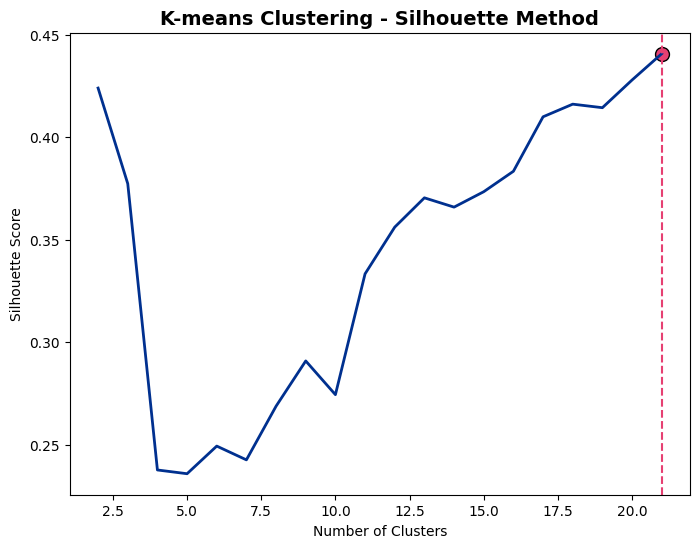

In [ ]:
# Ensure reproducibility
random_state = 42  

# Specify the range of k values to test
k_range = range(2, 22)

# Calculate the silhouette scores for each k value
silhouette_scores = []
best_k = None
best_score = -1 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)  
    cluster_labels = kmeans.fit_predict(result)
    
    score = silhouette_score(result, cluster_labels)
    silhouette_scores.append(score)
    
    # Store the best k based on silhouette score
    if score > best_score:
        best_score = score
        best_k = k

# Print the optimal k and its silhouette score
print(f"Optimal number of clusters (k) based on silhouette score: {best_k} with score: {best_score:.3f}")

# Plot the silhouette scores as a function of k
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, label="Silhouette Score", linewidth=2, color='#00308F')
plt.axvline(best_k, color='#e64072', linestyle='--', label=f"Optimal k = {best_k}")
plt.scatter(best_k, best_score, color='#e64072', s=100, edgecolors='black', label="Optimal Point")
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('K-means Clustering - Silhouette Method', fontsize=14, fontweight='bold')
plt.show()


<div style="text-align: justify;">
The Silhouette Score suggests that increasing the number of clusters improves the clustering quality, with the best result at k = 25. However, since this value is quite high, it may indicate over-segmentations, where the clustering algorithm is excessively dividing the data into smaller groups that may not be meaningful in a broader context.
<br><br>
To avoid this potential issue, we will cross-validate our result using the Elbow Method and Hierachical Clustering, which are more suited for detecting a balance between compactness and separation.
</div>

### 2.5. HIERARCHICAL CLUSTERING

<div style="text-align: justify;">
Finally, we also used Hierachical clustering. This is a bottom-up approach where each data point starts as its own cluster, and clusters are iteratively merged based on distance metrics (Ward's method). The resulting dendogram helps visualize the realtionship betweeen clusters, and by selecting an appropriate cut-off threshold (450), we aimed to achieve a blance between interpretrability and meaningful biological separation
</div>

Number of clusters at cut-off 450: 4


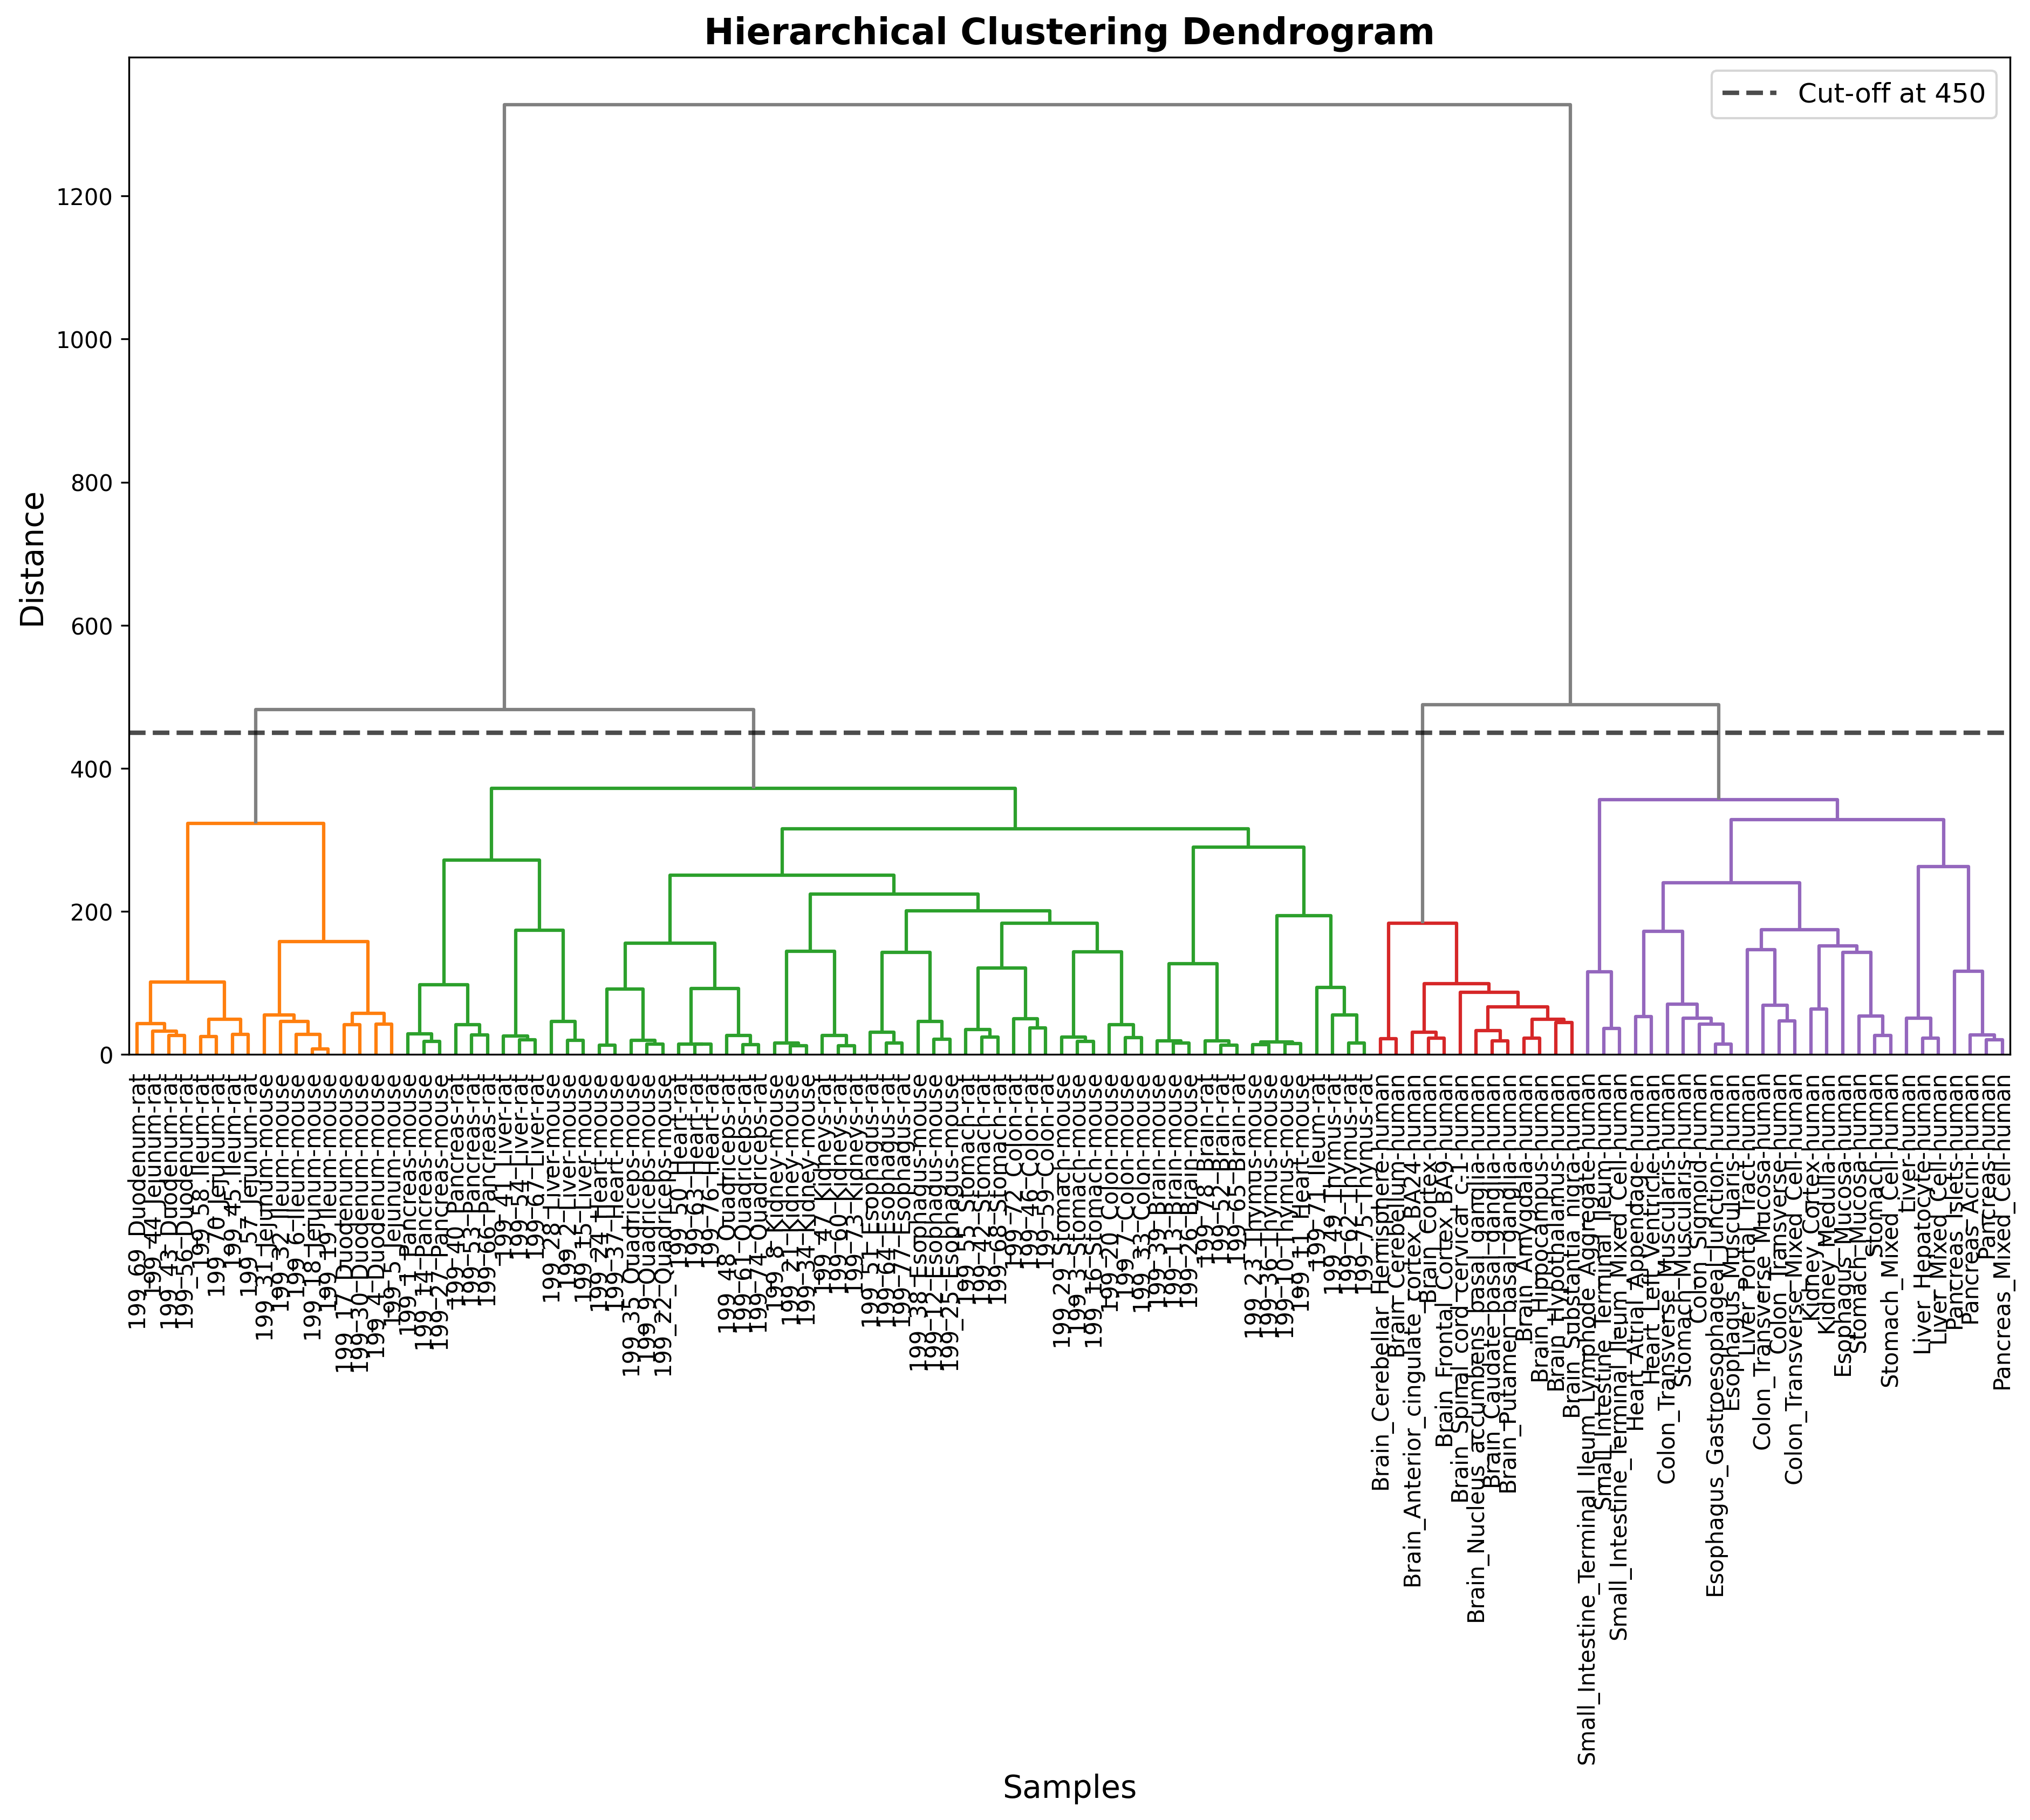

In [ ]:
# Compute linkage matrix
Z = linkage(result, method='ward')

# Set the cut-off value to 450
max_d = 450

# Generate clusters based on the new cut-off
clusters = fcluster(Z, max_d, criterion='distance')

print(f"Number of clusters at cut-off 450: {len(set(clusters))}")

# Improved Aesthetics
plt.figure(figsize=(15, 8), dpi=300)  
plt.title('Hierarchical Clustering Dendrogram', fontsize=16, fontweight='bold')
plt.xlabel('Samples', fontsize=14)
plt.ylabel('Distance', fontsize=14)

# Plot dendrogram with better visuals
dendrogram(
    Z,
    labels=result.index,  
    leaf_rotation=90, 
    leaf_font_size=10,  
    color_threshold=max_d,  
    above_threshold_color='gray'  
)

# Add cut-off line at 450
plt.axhline(y=max_d, color='black', linestyle='--', linewidth=2, alpha=0.7, label=f'Cut-off at {max_d}')
plt.legend(fontsize=12)

plt.show()


<div style="text-align: justify;">
The cut-off of 450 in the hierarchical clustering dendrogram was chosen as it represents a natural breakpoint where major clusters remain well-defined while preventing excessive merging of distinct groups. A higher cut-off would risk merging biologically distinct clusters, while a lower cut-off would result in excessive fragmentation, making interpretation difficult. Additionally, this threshold aligns with the K-means elbow method, which suggests a similar number of clusters, reinforcing the robustness of this choice. 
</div>

### 2.6. Cluster Number Selection
<div style="text-align: justify;">
We determined 4 clusters as the optimal number based on a combination of the Elbow Method and Hierachical Clustering. The Elbow Method cleary indicated k = 4 as the point where adding more clusters no longer signigicantly reduces WCSS, striking a balance between compactness and separation.
<br><br>
In hierarchical clustering, we faced a decision regarding the cut-off threshold. A higher cut-off resulted in fewer, broader clusters, whereas a lower cut-off led to a more fine-grained partitioning of the data. The cut-off at 450 allowed for a balanced clustering structure, forming four major clusters while preserving meaningful biological distinctions. This threshold effectively captures similarities without excessive fragmentation and aligns with a reasonable trade-off between granularity and interpretability. Given these observations, we determined that the chosen cut-off provides a biologically relevant partitioning of the data, though minor adjustments could be considered based on specific analytical needs.
</div>

In [23]:
number_of_clusters = 4

# Run k-means with the optimal number of clusters
kmeans = KMeans(n_clusters=number_of_clusters, random_state=0, n_init=10).fit(result)

# Run hierarchical clustering with the optimal number of clusters
hclustering = AgglomerativeClustering(n_clusters=number_of_clusters, linkage='ward').fit(result)

In [24]:
result['kmeans_cluster'] = kmeans.labels_
result['hierarchical_cluster'] = hclustering.labels_
heatmap_table=result.copy()

### 2.7. Compare the Clustering Results using both Methodologies
<div style="text-align: justify; color: #aaa7a7">
Compare the clustering results using both methodologies, and with the tissues/species. Show the results of the final partitions as a table.
</div>

<div style="text-align: justify;">
We merged the results from both clustering methods into a single table for camparisions. 
</div>

In [25]:
# Ensure index is a string before processing
result.index = result.index.astype(str)

# Extract species
result["species"] = result.index.str.split('-').str[-1].str.capitalize()  

# Extract tissue name (replace '_' with space)
def extract_tissue(index):
    parts = index.split('-')
    if len(parts) > 1:
        tissue = parts[0].replace('_', ' ')  
        if ' ' in tissue and tissue[0].isdigit():  
            tissue = " ".join(tissue.split(' ')[1:])  
        return tissue
    return "Unknown"

result["tissue"] = result.index.map(extract_tissue)

# Group by species, tissue, and cluster label
kmeans_tissue_counts = result.groupby(['species', 'tissue', 'kmeans_cluster']).size().reset_index(name='count')
hierarchical_tissue_counts = result.groupby(['species', 'tissue', 'hierarchical_cluster']).size().reset_index(name='count')

# Merge K-Means and Hierarchical Clustering results on species and tissue
merged_clusters = kmeans_tissue_counts.merge(
    hierarchical_tissue_counts, 
    on=['species', 'tissue'], 
    suffixes=('_kmeans', '_hierarchical')
).drop(columns=['count_kmeans', 'count_hierarchical'], errors='ignore')  

merged_clusters["kmeans_cluster"] += 1
merged_clusters["hierarchical_cluster"] += 1

sorted_table = merged_clusters.sort_values(by=["kmeans_cluster", "hierarchical_cluster"])

styled_sorted_table = sorted_table.rename(columns={
    "species": "Species",
    "tissue": "Tissue",
    "kmeans_cluster": "K-Means Cluster",
    "hierarchical_cluster": "Hierarchical Cluster"
})

print(tabulate(styled_sorted_table, headers="keys", tablefmt="fancy_grid"))

sorted_table.rename(columns={"tissue": "Tissue", "species": "Species"}, inplace=True)

╒═════╤═══════════╤═══════════════════════════════════════════════════╤═══════════════════╤════════════════════════╕
│     │ Species   │ Tissue                                            │   K-Means Cluster │   Hierarchical Cluster │
╞═════╪═══════════╪═══════════════════════════════════════════════════╪═══════════════════╪════════════════════════╡
│  13 │ Human     │ Colon Sigmoid                                     │                 1 │                      2 │
├─────┼───────────┼───────────────────────────────────────────────────┼───────────────────┼────────────────────────┤
│  14 │ Human     │ Colon Transverse                                  │                 1 │                      2 │
├─────┼───────────┼───────────────────────────────────────────────────┼───────────────────┼────────────────────────┤
│  15 │ Human     │ Colon Transverse Mixed Cell                       │                 1 │                      2 │
├─────┼───────────┼─────────────────────────────────────────────

<div style="text-align: justify;">
The clustering analysis demonstrates a high degree of consistency between K-Means and Hierarchical Clustering, as both methods produce the same major clusters, reinforcing the biological validity of the results. A key observation is the distinct grouping of human brain tissues, which cluster together independently from other organ systems.
Another crucial pattern observed is the species-specific clustering of tissues. Human tissues cluster separately from mouse and rat tissues. This separation may reflect evolutionary divergence in gene expression patterns, cellular composition, or metabolic processes.
Overall, the clustering results effectively capture biologically meaningful patterns, highlighting both species- and tissue-specific relationships.
</div>

<div style="text-align: justify; color: #aaa7a7">
Plot a heatmap of the 50 genes with top variance over all samples. Add the information about tissue groups and model (human, rat and mouse) as annotations in the heatmap.
</div>

<div style="text-align: justify;">
First, we cleaned the datset by removing unnecessary columns and duplicate rows, and ensuring that index labels are unique. 
</div>

In [26]:
heatmap_table = heatmap_table.T
rez = heatmap_table.T.drop(columns=['hierarchical_cluster','kmeans_cluster'])
rez = rez.T
rez.drop_duplicates(inplace=True)
rez = rez[~rez.index.duplicated(keep='first')]

<div style="text-align: justify;">
We calculated the variance across all samples for each genes and we selected the top 50 genes with the highest variance by sorting the variance values in descending order.
</div>

In [27]:
gene_variances = rez.var(axis=1)
top_variances = gene_variances.nlargest(50).index
result_top_variances = rez.loc[top_variances]

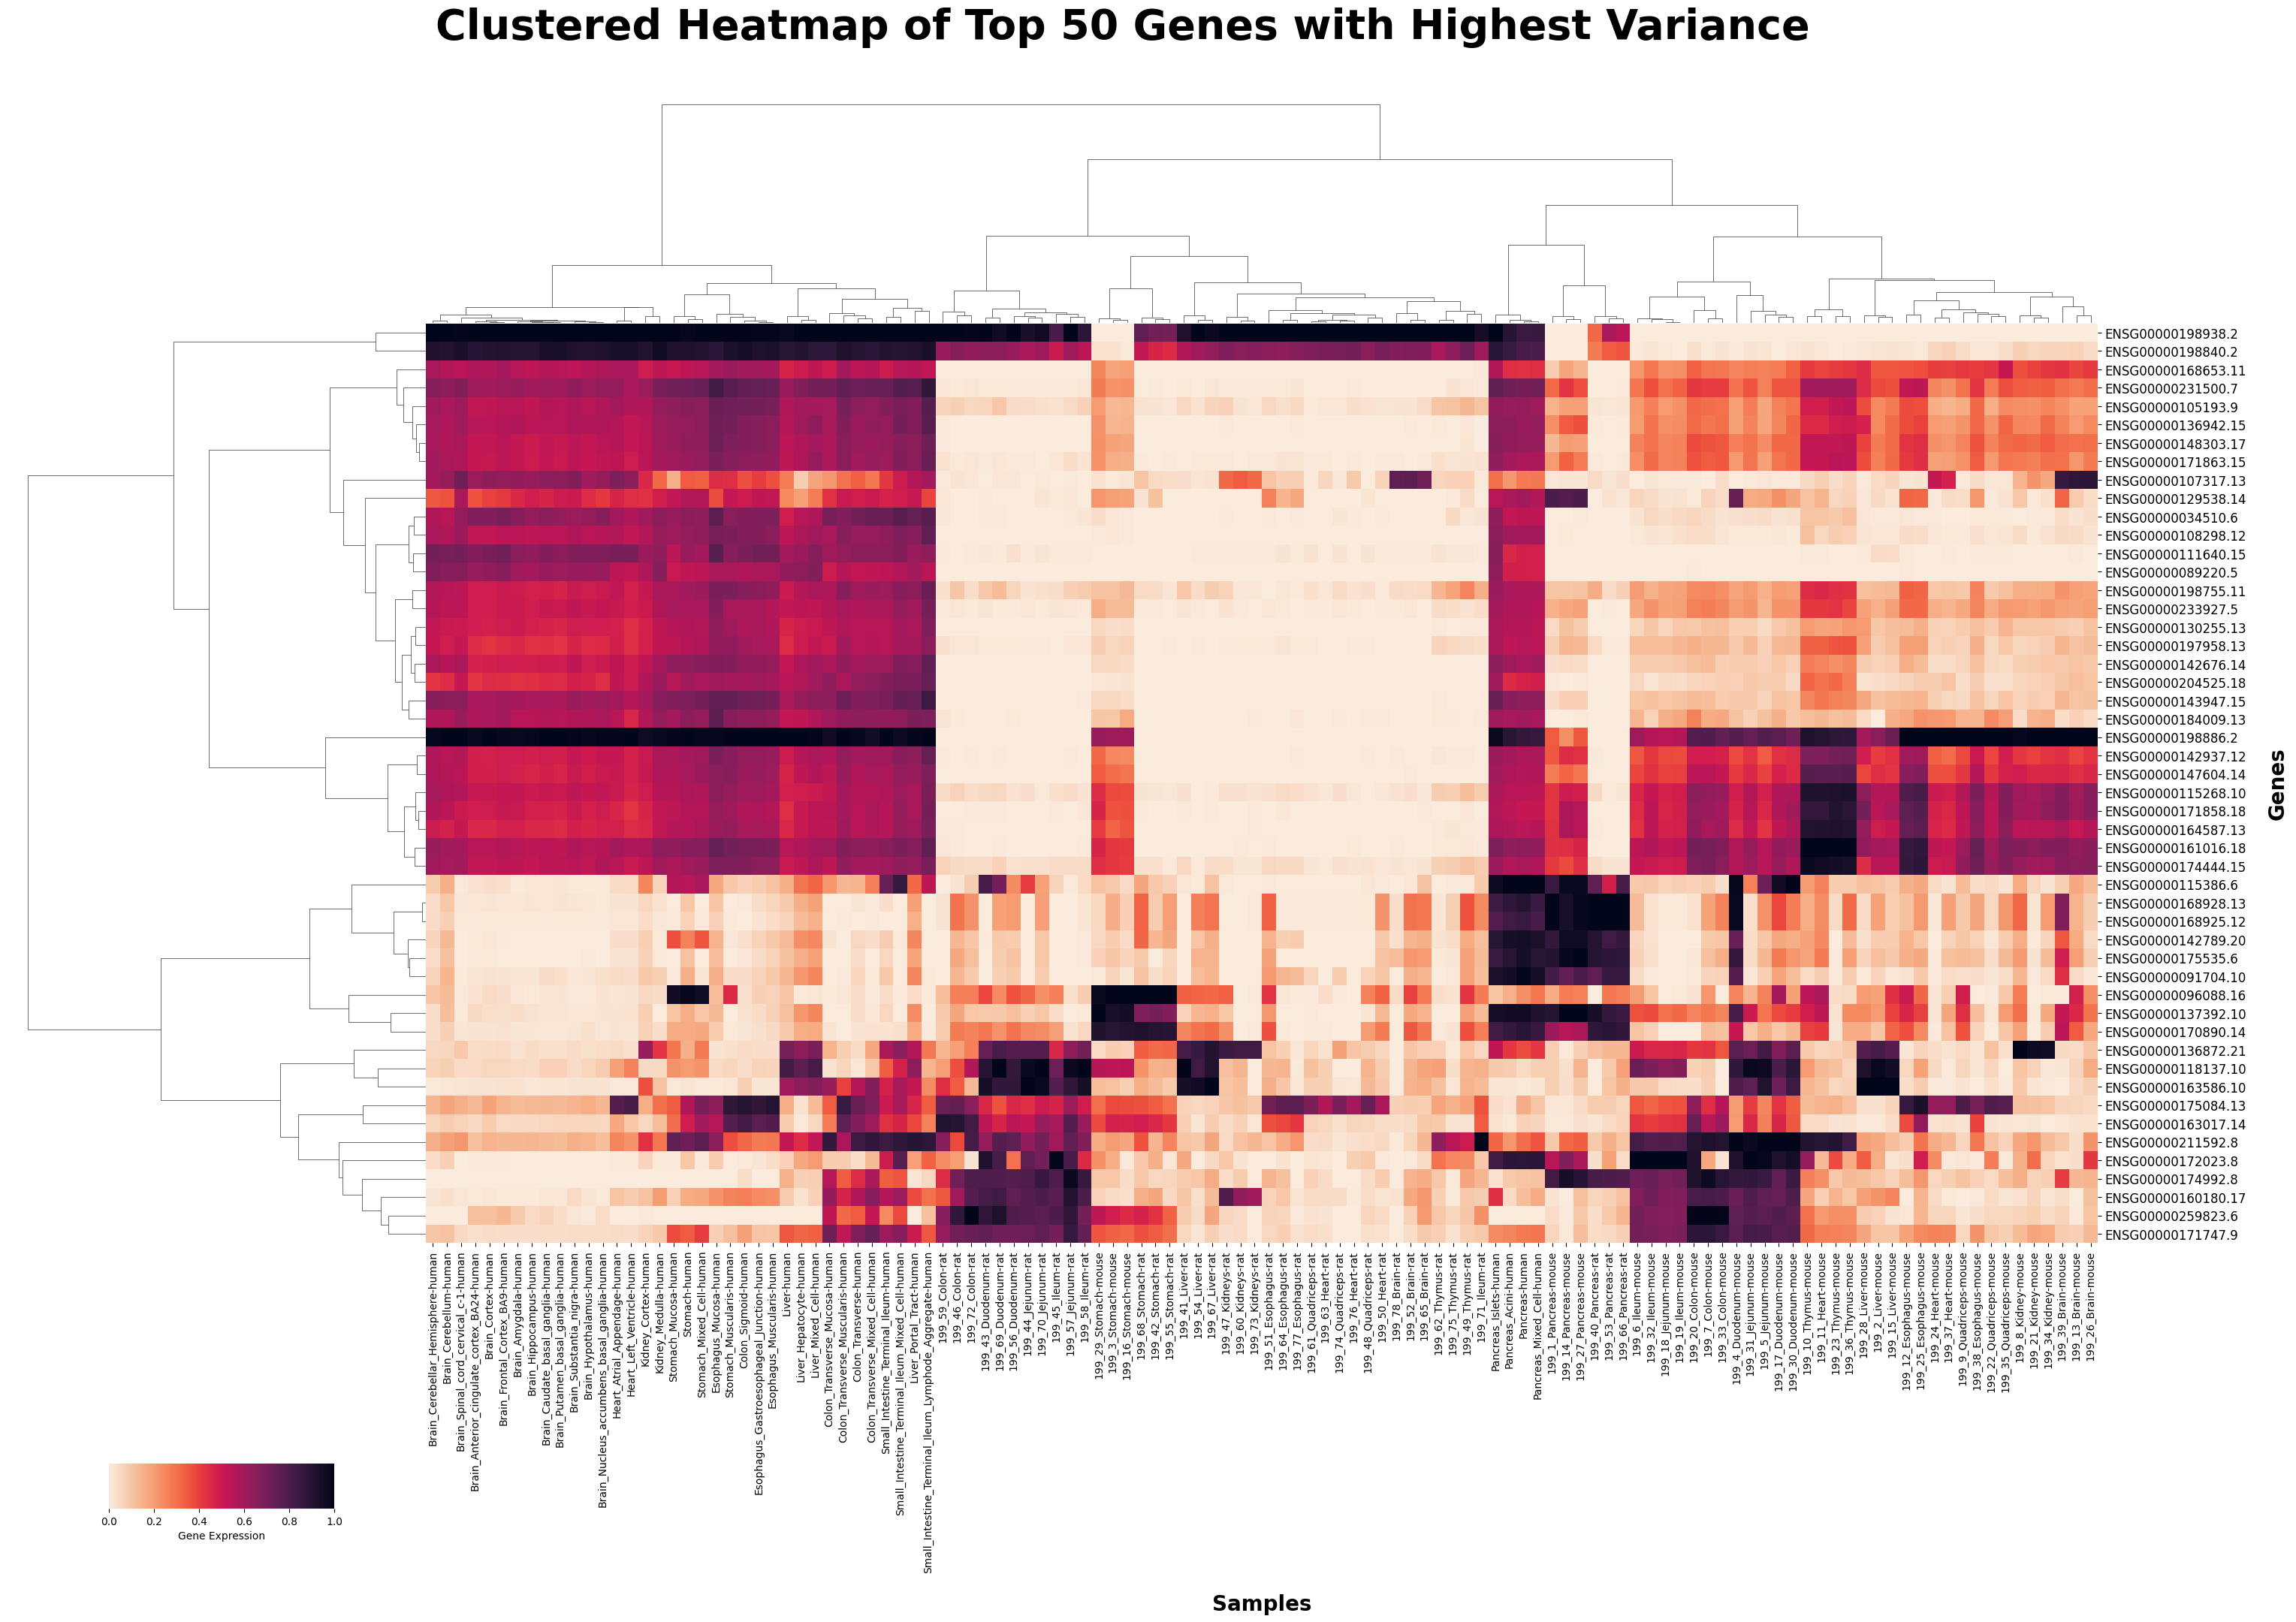

In [33]:
clustermap = sns.clustermap(
    result_top_variances,
    cmap=sns.color_palette("rocket_r", as_cmap=True),
    standard_scale=1,
    figsize=(30, 20),  
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.2,
    method='ward',
    cbar_kws={'label': 'Gene Expression', 'shrink': 0.3, 'orientation': 'horizontal'},  
    cbar_pos=(0.05, 0.05, 0.1, 0.03)  
)

clustermap.fig.suptitle(
    "Clustered Heatmap of Top 50 Genes with Highest Variance",
    fontsize=40, fontweight='bold', y=1.05, ha='center'
)

clustermap.ax_heatmap.set_xlabel("Samples", fontsize=20, fontweight='bold', labelpad=20)
clustermap.ax_heatmap.set_ylabel("Genes", fontsize=20, fontweight='bold', labelpad=20)

plt.setp(clustermap.ax_heatmap.get_xticklabels(), rotation=90, fontsize=10, ha='center')
plt.setp(clustermap.ax_heatmap.get_yticklabels(), fontsize=12)

plt.show()

## 3. PCA

### 3.1. PCA of Gene Expression Data (labeled by tissues/model)

<div style="text-align: justify; color: #aaa7a7">
With the gene expression for different tissues and models, perform a PCA on the data and visualize the results (PC1 and PC2, and also, PC3). Label the points in the plot with their respective tissues/models.
</div>

<div style="text-align: justify">
First, we prepared the data for PCA visualization by assigning unique colors to tissues and distinct marker shapes to species.
</div>

In [34]:
# Copy the heatmap table
pca_table = heatmap_table.copy()
pca_table = (pca_table).loc[:, ~pca_table.columns.duplicated()]

# Create dictionaries to map species to shapes and tissues to colors
unique_tissues = set()
for col_name in pca_table.columns:
    tissue = next((t for t in tissues if t in col_name.lower()), col_name)
    unique_tissues.add(tissue.capitalize())

colormap = cm.rainbow(np.linspace(0, 1, len(unique_tissues)))
tissue_colors = {tissue: colormap[i] for i, tissue in enumerate(sorted(unique_tissues))}

species_markers = {
    'human': 'o',    
    'rat': 's',      
    'mouse': '^'     
}

colors = []
shape_markers = []
tissue_labels = []  

for col_name in pca_table.columns:
    
    # Extract the tissue name from the column label
    matched_tissue = next((t for t in tissues if t in col_name.lower()), col_name)
    tissue_name = matched_tissue.capitalize()
    tissue_labels.append(tissue_name)
    
    # Assign colors based on tissue
    colors.append(tissue_colors[tissue_name])
    
    # Assign shapes based on species
    if col_name.endswith('-human'):
        shape_markers.append(species_markers['human'])
    elif col_name.endswith('-rat'):
        shape_markers.append(species_markers['rat'])
    elif col_name.endswith('-mouse'):
        shape_markers.append(species_markers['mouse'])



<div style="text-align: justify">
PCA was applied to reduce the dimensionality of the dataset while preserving as much variance as possible. 
</div>

In [35]:
# Apply PCA
pca = PCA(n_components=3)
pca.fit(pca_table.T)
result_pca = pca.transform(pca_table.T)

<div style="text-align: justify">
A 2D PCA plot (PC1 vs PC2) was generated to visualize gene expression patterns across different tissues and species. Each point represents a sample, with color indicating tissue type and marker shape corresponding to species. Additionally, the same process was repeated for PC1 vs PC3 and PC2 vs PC3 to explore variance distribution across different principal components.
</div>

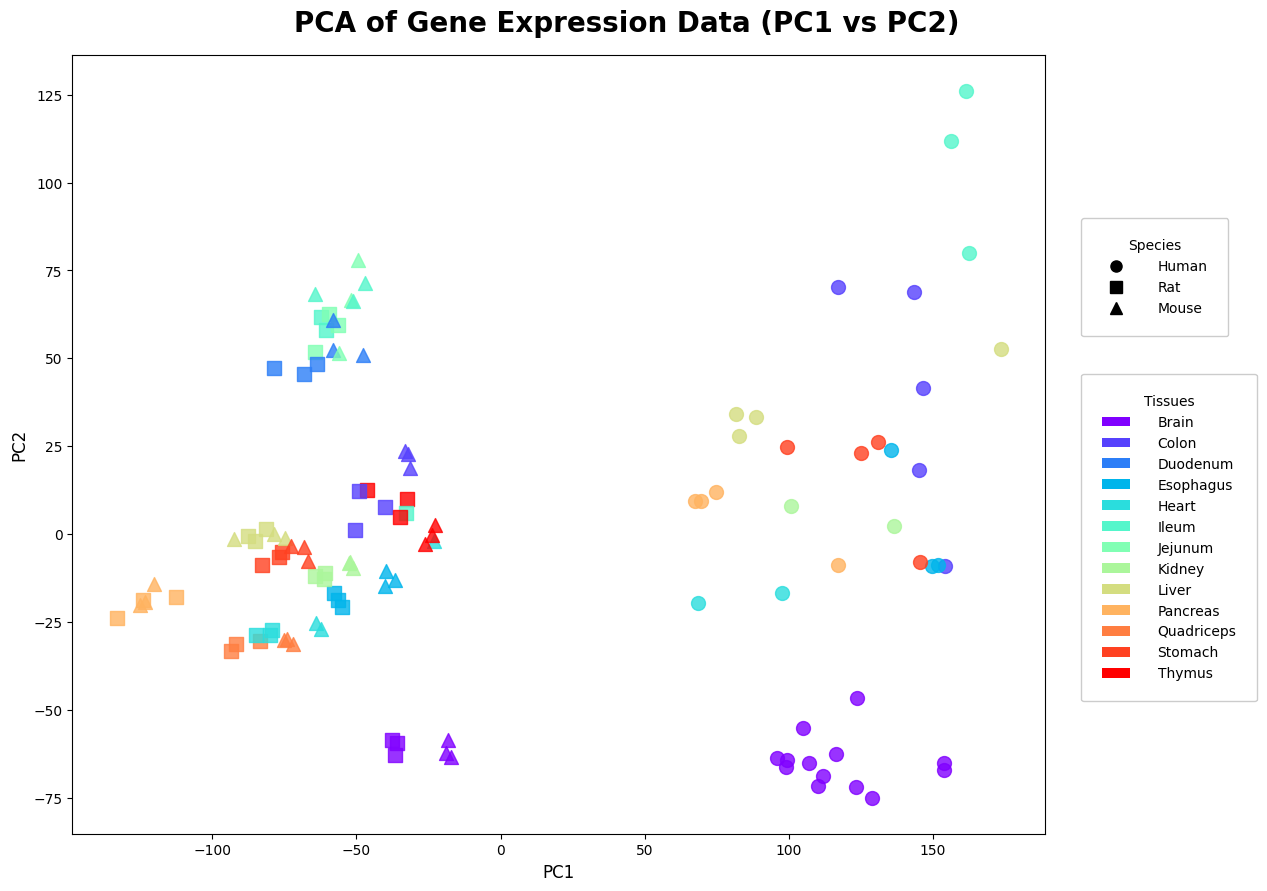

In [36]:
# Create a 2D PCA Plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(14, 9))  

# Plot each point with its specific marker and color
for i in range(len(result_pca)):
    ax.scatter(
        result_pca[i, 0],
        result_pca[i, 1],
        color=colors[i],
        marker=shape_markers[i],
        s=100,  
        alpha=0.8
    )

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA of Gene Expression Data (PC1 vs PC2)', fontsize=20, fontweight='bold', y=1.02, x=0.57)

# Create species marker legend
species_handles = [
    Line2D([0], [0], marker=marker, color='black', label=species.capitalize(),
           markersize=8, linestyle='None')
    for species, marker in species_markers.items()
]
species_legend = ax.legend(
    handles=species_handles, 
    title="Species", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.8),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)
ax.add_artist(species_legend)

# Create tissue color legend
tissue_handles = [
    Patch(facecolor=color, label=tissue)
    for tissue, color in tissue_colors.items()
]
tissue_legend = ax.legend(
    handles=tissue_handles, 
    title="Tissues", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.6),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)


plt.tight_layout()
plt.subplots_adjust(right=0.75)  

<div style="text-align: justify">
The PCA plot of gene expression data reveals distinct clustering patterns based on both tissue type and species.
                                                                                    
One of the most striking observations is the clear separation of brain samples (colored in purple) from all other tissue types. This strong clustering suggests that brain tissues exhibit a highly distinct gene expression profile compared to other organs, reinforcing their specialized molecular function. Similarly, rat and mouse intestinal tissues such as dudodenum and jejunum separate from the rest, suggesting strong tissue-specific transcriptional profile. In contrast, liver, kidney, and heart tissues exhibit greater spread.

Human samples tend to occupy distinct regions in the PCA space, particularly for brain, whereas rat and mouse samples appear more intermixed. This separation highlights species-dependent differences in gene expression, potentially reflecting evolutionary divergence or differences in experimental conditions.
</div>

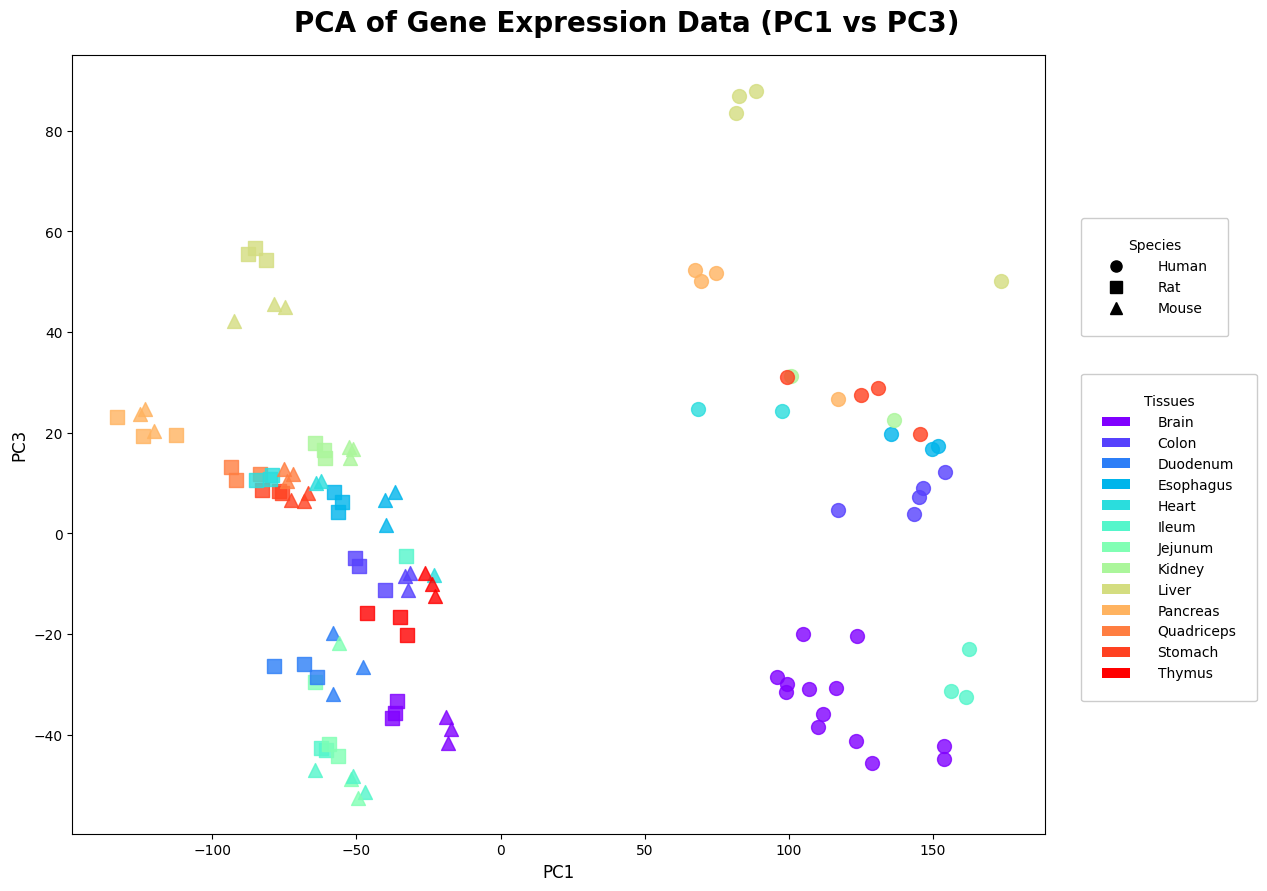

In [37]:
# Create a 2D PCA Plot (PC1 vs PC3)
fig, ax = plt.subplots(figsize=(14, 9))  

# Plot each point with its specific marker and color
for i in range(len(result_pca)):
    ax.scatter(
        result_pca[i, 0],  # PC1
        result_pca[i, 2],  # PC3
        color=colors[i],
        marker=shape_markers[i],
        s=100,  
        alpha=0.8
    )

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC3', fontsize=12)
ax.set_title('PCA of Gene Expression Data (PC1 vs PC3)', fontsize=20, fontweight='bold', y=1.02, x=0.57)

# Create species marker legend
species_legend = ax.legend(
    handles=species_handles, 
    title="Species", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.8),  
    frameon=True, framealpha=1, borderpad=1.5, handletextpad=2
)
ax.add_artist(species_legend)

# Create tissue color legend
tissue_legend = ax.legend(
    handles=tissue_handles, 
    title="Tissues", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.6),  
    frameon=True, framealpha=1, borderpad=1.5, handletextpad=2
)

plt.tight_layout()
plt.subplots_adjust(right=0.75)  
plt.show()

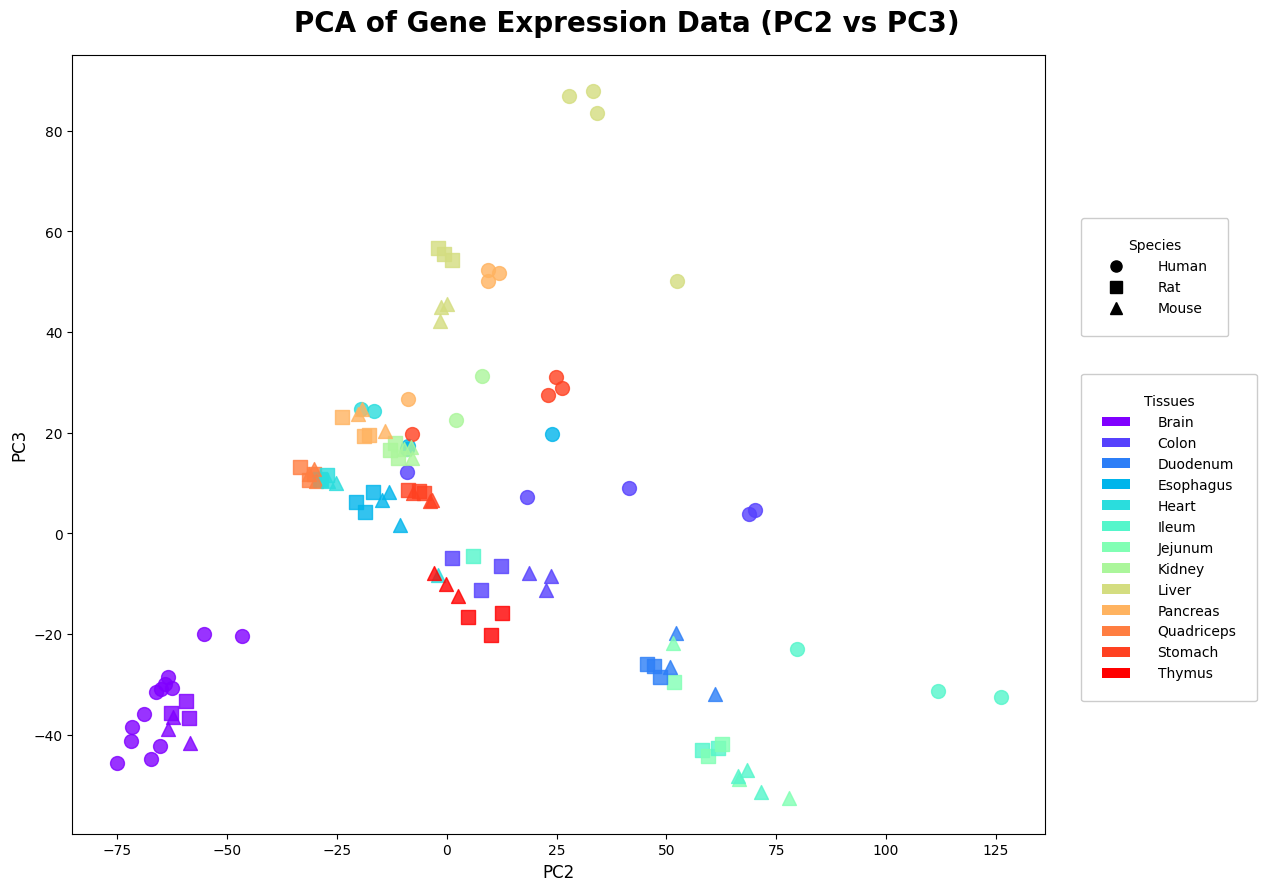

In [38]:
# Create a 2D PCA Plot (PC2 vs PC3)
fig, ax = plt.subplots(figsize=(14, 9))  

# Plot each point with its specific marker and color
for i in range(len(result_pca)):
    ax.scatter(
        result_pca[i, 1],  # PC2
        result_pca[i, 2],  # PC3
        color=colors[i],
        marker=shape_markers[i],
        s=100,  
        alpha=0.8
    )

ax.set_xlabel('PC2', fontsize=12)
ax.set_ylabel('PC3', fontsize=12)
ax.set_title('PCA of Gene Expression Data (PC2 vs PC3)', fontsize=20, fontweight='bold', y=1.02, x=0.57)

# Create species marker legend
species_legend = ax.legend(
    handles=species_handles, 
    title="Species", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.8),  
    frameon=True, framealpha=1, borderpad=1.5, handletextpad=2
)
ax.add_artist(species_legend)

# Create tissue color legend
tissue_legend = ax.legend(
    handles=tissue_handles, 
    title="Tissues", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.6),  
    frameon=True, framealpha=1, borderpad=1.5, handletextpad=2
)

plt.tight_layout()
plt.subplots_adjust(right=0.75)  
plt.show()

<div style="text-align: justify">
A 3D PCA plot (PC1, PC2, PC3) was generated to visualize the gene expression patterns across different tissues and species in a three-dimensional space. 
</div>

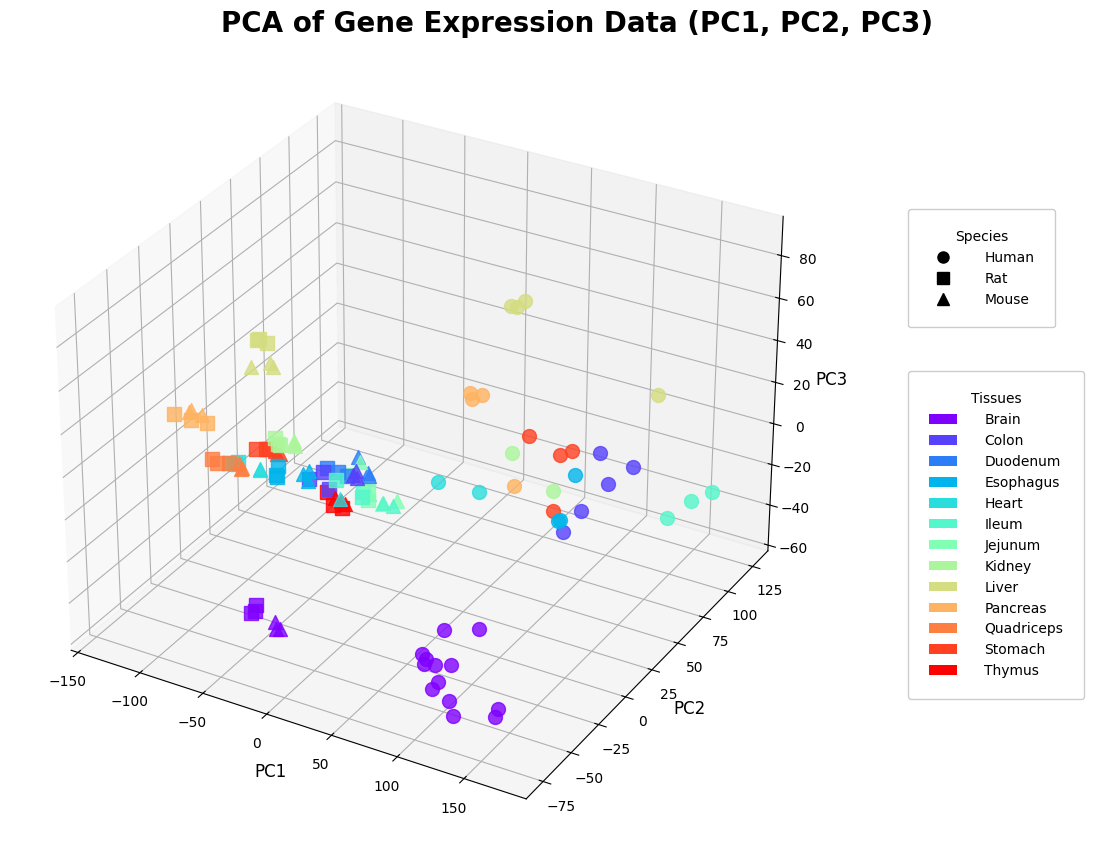

In [39]:
# Create a 3D PCA Plot (PC1, PC2, PC3)
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot each point with its specific marker and color
for i in range(len(result_pca)):
    ax.scatter(
        result_pca[i, 0], 
        result_pca[i, 1], 
        result_pca[i, 2], 
        color=colors[i], 
        marker=shape_markers[i], 
        s=100,  
        alpha=0.8
    )

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_zlabel('PC3', fontsize=12)
ax.set_title('PCA of Gene Expression Data (PC1, PC2, PC3)', fontsize=20, fontweight='bold', x = 0.7)

# Move species legend outside the plot 
species_legend = ax.legend(
    handles=species_handles, 
    title="Species", 
    loc="upper left", 
    bbox_to_anchor=(1.1, 0.8),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)
ax.add_artist(species_legend)

# Create tissue legend with same width settings
tissue_legend = ax.legend(
    handles=tissue_handles, 
    title="Tissues", 
    loc="upper left", 
    bbox_to_anchor=(1.1, 0.6),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)

# Adjust layout to ensure space for legends
plt.subplots_adjust(right=0.8) 
plt.show()

<div style="text -justified">
The 3D PCA plot highlights distinct clustering patterns. Brain tissues (purple) remain tightly clustered across species, indicating a highly conserved gene expression profile. Metabolic tissues such as the liver (green) and pancreas (orange) also remain separate, reinforcing their unique transcriptional regulation. However, kidney, and intestinal tissues (cyan, light green, and blue) display greater dispersion, suggesting higher intra-tissue variability.
</div>

### 3.2. PCA of Gene Expression Data (labeled by k-means cluster)

<div style="text-align: justify; color: #aaa7a7">
Visualize the data using the PC1 and PC2 again, but this time, color the observations by cluster, using the k means clusters, with k of your choice. Produce a caption for the plot
</div>

In [40]:
# Ensure indices match
pca_table_sorted = pca_table.T.loc[result.index]  

# Apply PCA
pca = PCA(n_components=3)
result_pca = pca.fit_transform(pca_table_sorted)

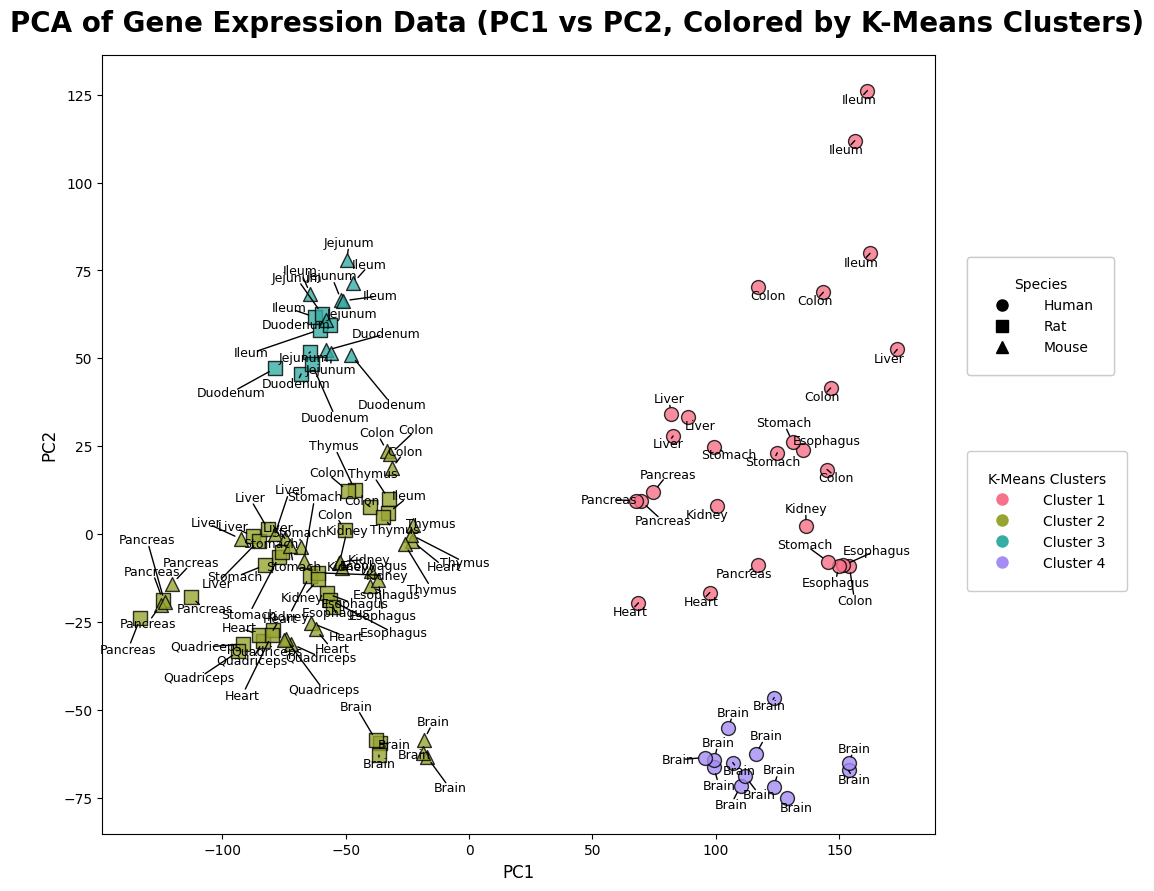

In [74]:
cluster_labels = result["kmeans_cluster"].values
species_labels = result["species"].values

# Define a color palette for clusters
num_clusters = len(set(cluster_labels))  # Count unique clusters
cluster_palette = sns.color_palette("husl", num_clusters)  # Generate distinct colors
cluster_colors = [cluster_palette[label] for label in cluster_labels]  # Map colors

# Define tissue names mapping
tissue_labels = []  
for col_name in pca_table.columns:
    matched_tissue = next((t for t in tissues if t in col_name.lower()), col_name)
    tissue_labels.append(matched_tissue.capitalize())  # Standardize capitalization

# Create a colormap for tissues
unique_tissues = sorted(set(tissue_labels))  # Unique tissue names
colormap = cm.rainbow(np.linspace(0, 1, len(unique_tissues)))
tissue_colors = {tissue: colormap[i] for i, tissue in enumerate(unique_tissues)}

# Define marker shapes for species
species_markers = {
    'Human': 'o',  # Circle
    'Rat': 's',    # Square
    'Mouse': '^'   # Triangle
}

# Assign marker shapes based on species
shape_markers = [species_markers[species] for species in species_labels]

# Create a 2D PCA Plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(14, 9))  

# Store text elements for later adjustment
texts = []

# Scatter plot with tissue labels
for i in range(len(result_pca)):
    ax.scatter(
        result_pca[i, 0],
        result_pca[i, 1],
        color=cluster_colors[i],  
        marker=shape_markers[i],
        s=100,  
        alpha=0.8,
        edgecolors="black"
    )
    # Store text labels for later adjustment
    texts.append(ax.text(
        result_pca[i, 0],  
        result_pca[i, 1],  
        tissue_labels[i],  
        fontsize=9, color='black', ha='center', va='center'
    ))

# Adjust text labels to avoid overlapping
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", lw=1, color='black', shrinkA=5, shrinkB=5),  # Fine-tuned arrow shrinking
    force_points=3.0,  # Stronger repulsion from data points
    force_text=3.0,  # Stronger repulsion between text labels
    expand_points=(3.0, 3.0),  # Expand space around points to prevent text overlap
    expand_text=(3.0, 3.0),  # Expand space around text labels to avoid clustering
    only_move={'points': 'xy', 'text': 'xy'},  # Allow movement in both X and Y directions
    lim=600  # More iterations for better spacing
)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA of Gene Expression Data (PC1 vs PC2, Colored by K-Means Clusters)', 
             fontsize=20, fontweight='bold', y=1.02, x=0.57)

# Create cluster legend
cluster_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_palette[i], 
           markersize=10, label=f'Cluster {i+1}', linestyle='None')
    for i in range(num_clusters)
]
cluster_legend = ax.legend(
    handles=cluster_handles, 
    title="K-Means Clusters", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.5),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)
ax.add_artist(cluster_legend) 

# Create species legend
species_handles = [
    Line2D([0], [0], marker=marker, color='black', label=species,
           markersize=8, linestyle='None')
    for species, marker in species_markers.items()
]
species_legend = ax.legend(
    handles=species_handles, 
    title="Species", 
    loc="upper left", 
    bbox_to_anchor=(1.03, 0.75),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)
ax.add_artist(species_legend)

plt.tight_layout()
plt.subplots_adjust(right=0.65)  
plt.show()

<div style="text -justified">
A key observation is the clear separation of clusters, suggesting that K-Means effectively groups samples with similar transcriptional profiles. Cluster 1 (pink) contains a distinct set of human samples positioned far along the PC1 axis, indicating that these samples share strong gene expression similarities that set them apart from the rest. Cluster 4 (purple), also composed of human samples, is located at the lower end of PC2, further reinforcing the idea of specialized gene expression profiles in these tissues. Meanwhile, Clusters 2 (green) and 3 (blue) primarily consist of rodent (mouse and rat) samples, which cluster closely together. 
</div>

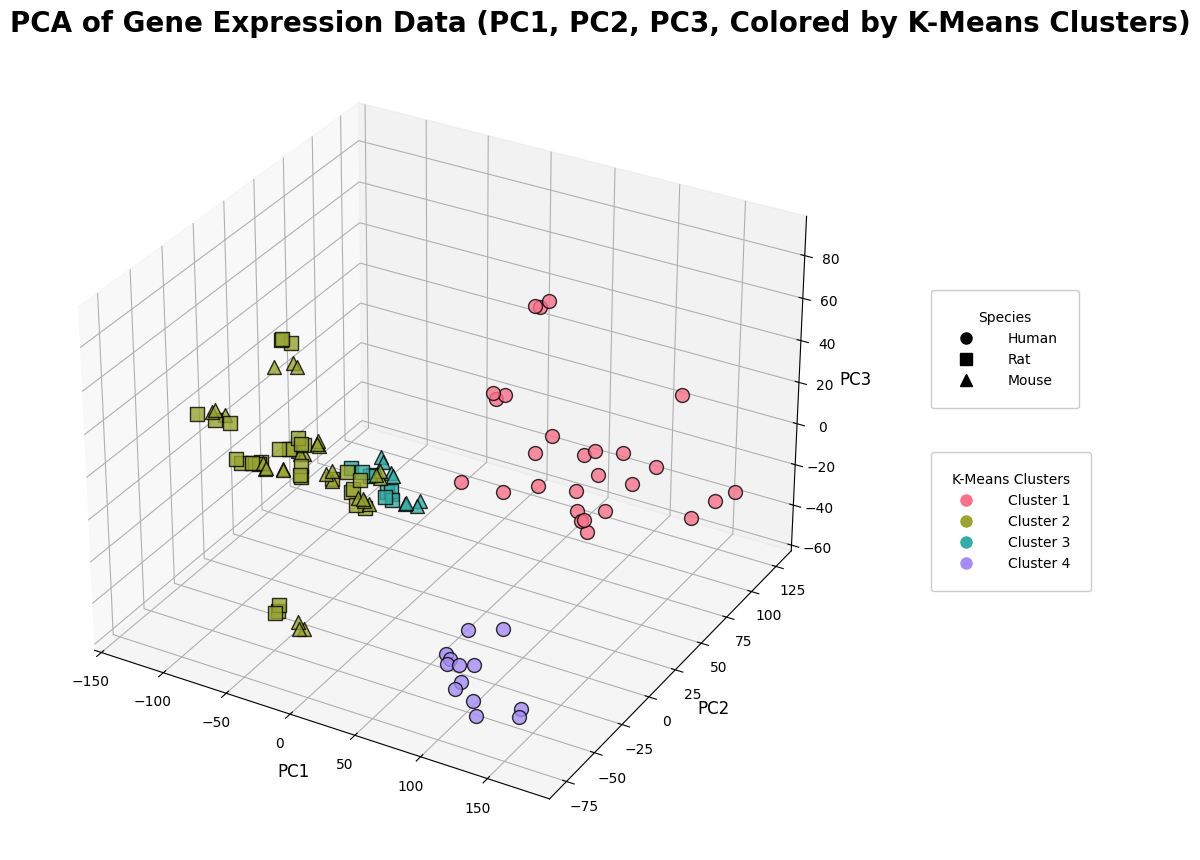

In [75]:
# Create a 3D PCA Plot (PC1, PC2, PC3)
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot each point with corresponding cluster color and species marker
for i in range(len(result_pca)):
    ax.scatter(
        result_pca[i, 0], 
        result_pca[i, 1], 
        result_pca[i, 2], 
        color=cluster_colors[i],  
        marker=shape_markers[i],  
        s=100,  
        alpha=0.8,
        edgecolors="black"
    )

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_zlabel('PC3', fontsize=12)
ax.set_title('PCA of Gene Expression Data (PC1, PC2, PC3, Colored by K-Means Clusters)', 
             fontsize=20, fontweight='bold', x=0.7)

# Create cluster legend
cluster_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_palette[i], 
           markersize=10, label=f'Cluster {i+1}', linestyle='None')
    for i in range(num_clusters)
]
cluster_legend = ax.legend(
    handles=cluster_handles, 
    title="K-Means Clusters", 
    loc="upper left", 
    bbox_to_anchor=(1.1, 0.5),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)
ax.add_artist(cluster_legend)  

# Create species legend
species_handles = [
    Line2D([0], [0], marker=marker, color='black', label=species,
           markersize=8, linestyle='None')
    for species, marker in species_markers.items()
]
species_legend = ax.legend(
    handles=species_handles, 
    title="Species", 
    loc="upper left", 
    bbox_to_anchor=(1.1, 0.7),  
    frameon=True,               
    framealpha=1,               
    borderpad=1.5,              
    handletextpad=2             
)

# Adjust layout to ensure space for legends
plt.subplots_adjust(right=0.8)  
plt.show()


<div style="text -justified">
In this plot, the cluster 4 (purple) is well-isolated, reinforcing that it likely represents a highly distinct tissue group (maybe brain, based on previous PCA results). Clusters 2 (green) and 3 (blue) are more dispersed, suggesting greater heterogeneity in expression profiles or possibly mixed tissue types.
</div>

### 3.3. Top 50 genes that contribute to the PC1

<div style="text-align: justify; color: #aaa7a7">
What are the top 50 genes that contribute to the PC1? Are they the same genes that are more variable according to the exercise 1?
</div>

In [76]:
# Get the loadings (eigenvectors) for PC1
pc1_loadings = pca.components_[0]  

# Sort genes by absolute contribution to PC1 and select the top 50 unique genes
top_genes_pc1 = np.argsort(np.abs(pc1_loadings))[::-1]
gene_names_pc1 = list(dict.fromkeys(pca_table.T.columns[top_genes_pc1]))[:50]  

# Print the names of the 50 genes
print("Top 50 genes contributing to PC1:")
for gene in gene_names_pc1:
    print(gene)

Top 50 genes contributing to PC1:
ENSG00000198886.2
ENSG00000198840.2
ENSG00000111640.15
ENSG00000034510.6
ENSG00000198938.2
ENSG00000143947.15
ENSG00000136942.15
ENSG00000108298.12
ENSG00000089220.5
ENSG00000231500.7
ENSG00000184009.13
ENSG00000142676.14
ENSG00000204525.18
ENSG00000105193.9
ENSG00000074800.16
ENSG00000148303.17
ENSG00000101439.9
ENSG00000130255.13
ENSG00000198755.11
ENSG00000149806.11
ENSG00000135940.7
ENSG00000171863.15
ENSG00000233927.5
ENSG00000197958.13
ENSG00000142541.18
ENSG00000168653.11
ENSG00000142937.12
ENSG00000135390.21
ENSG00000161016.18
ENSG00000089157.16
ENSG00000164032.12
ENSG00000123416.15
ENSG00000147604.14
ENSG00000185883.12
ENSG00000182154.8
ENSG00000134590.14
ENSG00000108107.15
ENSG00000186468.13
ENSG00000177700.6
ENSG00000088986.11
ENSG00000092841.19
ENSG00000132341.12
ENSG00000166441.13
ENSG00000182899.17
ENSG00000174444.15
ENSG00000107317.13
ENSG00000111676.15
ENSG00000135486.19
ENSG00000022267.19
ENSG00000156508.19


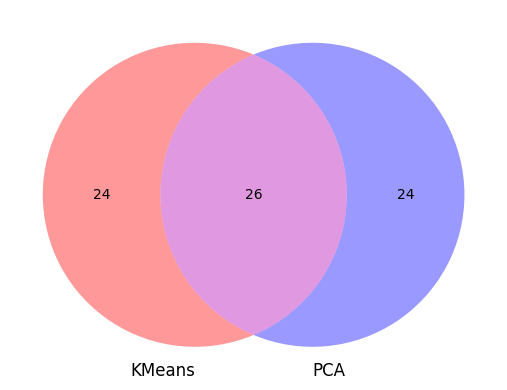


KMeans unique:
1.	ENSG00000168925.12
2.	ENSG00000172023.8
3.	ENSG00000259823.6
4.	ENSG00000174992.8
5.	ENSG00000175084.13
6.	ENSG00000096088.16
7.	ENSG00000137392.10
8.	ENSG00000168928.13
9.	ENSG00000160180.17
10.	ENSG00000175535.6
11.	ENSG00000118137.10
12.	ENSG00000136872.21
13.	ENSG00000164587.13
14.	ENSG00000115268.10
15.	ENSG00000163586.10
16.	ENSG00000091704.10
17.	ENSG00000129538.14
18.	ENSG00000170890.14
19.	ENSG00000171858.18
20.	ENSG00000171747.9
21.	ENSG00000115386.6
22.	ENSG00000211592.8
23.	ENSG00000142789.20
24.	ENSG00000163017.14

PC1 unique:
1.	ENSG00000166441.13
2.	ENSG00000089157.16
3.	ENSG00000182154.8
4.	ENSG00000111676.15
5.	ENSG00000022267.19
6.	ENSG00000149806.11
7.	ENSG00000135486.19
8.	ENSG00000092841.19
9.	ENSG00000186468.13
10.	ENSG00000135390.21
11.	ENSG00000142541.18
12.	ENSG00000177700.6
13.	ENSG00000164032.12
14.	ENSG00000185883.12
15.	ENSG00000074800.16
16.	ENSG00000135940.7
17.	ENSG00000134590.14
18.	ENSG00000132341.12
19.	ENSG00000088986.11
20.	ENSG00

In [77]:
venn2([set(top_variances), set(gene_names_pc1)], set_colors=('red', 'blue'), set_labels=('KMeans', 'PCA'))
plt.show()

km_set = set(top_variances) - set(gene_names_pc1)
pc1_set = set(gene_names_pc1) - set(top_variances)
inter_set = set(top_variances).intersection(set(gene_names_pc1))

print("\nKMeans unique:")
for x, i in enumerate(km_set):
  print(x+1, '.\t', i, sep='')

print("\nPC1 unique:")
for x, i in enumerate(pc1_set):
  print(x+1, '.\t', i, sep='')

print("\nIntersect:")
for x, i in enumerate(inter_set):
  print(x+1, '.\t', i, sep='')

<div style="text -justified">

24 genes were identified as important for distinguish clusters in the k-means clustering approach but were not among the top genes contributing to PC1 in PCA. 24 genes were identified as key contributors to PC1 in the PCA analysis but were not used in K-Means clustering.

The overlapping region represents genes that were identified as important in both methods. These 26 genes contribute significantly to PC1 and also play a key role in the clustering process in K-Means.

</div>

### 3.4. tSNE

<div style="text-align: justify; color: #aaa7a7">
Perform t-SNE on the dataset and visualize the results. Test at least 2 perplexity values.
</div>

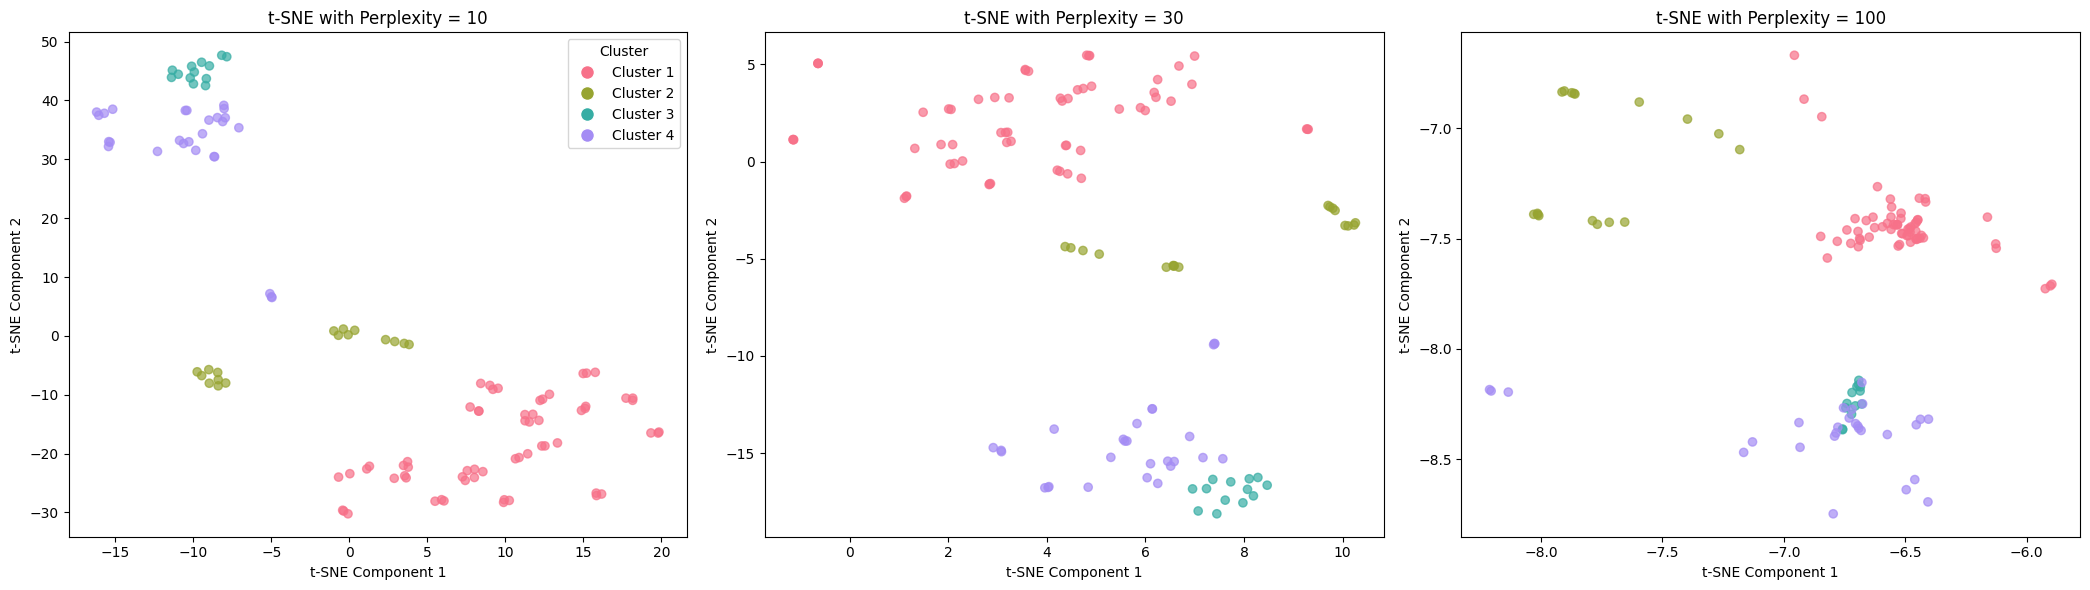

In [78]:
# Select numeric columns and remove NaN values
numeric_cols = result.select_dtypes(include=['number']).columns
X = result[numeric_cols].dropna()

# Generate a color palette with distinct colors for clusters
num_clusters = len(set(cluster_labels)) 
cluster_palette = sns.color_palette("husl", num_clusters)  
cluster_colors = [cluster_palette[label - 1] for label in cluster_labels]  

# Perform t-SNE with three perplexity values
perplexities = [10, 30, 100]
tsne_results = {}

for perplexity in perplexities:
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42,   max_iter=5000, learning_rate=200)
    tsne_results[perplexity] = tsne.fit_transform(X)

# Plot the results using custom colors
fig, axes = plt.subplots(1, 3, figsize=(21, 6))  
for ax, (perplexity, tsne_data) in zip(axes, tsne_results.items()):
    scatter = ax.scatter(tsne_data[:, 0], tsne_data[:, 1], color=cluster_colors, alpha=0.7)  
    ax.set_title(f"t-SNE with Perplexity = {perplexity}")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")

# Create custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Cluster {i+1}')
                  for i, color in enumerate(cluster_palette)]
axes[0].legend(handles=legend_patches, title="Cluster", loc='upper right')

plt.tight_layout()
plt.show()

<div style="text -justified">

At perplexity = 10, the clusters are well-separated, with distinct groupings visible for Cluster 1 (red), Cluster 2 (green), Cluster 3 (cyan), and Cluster 4 (purple). This suggests that at low perplexity, t-SNE prioritizes local relationships, leading to compact and clearly defined clusters. However, the distances between clusters may not fully reflect their global relationships in the original data.

With perplexity = 30, the clusters remain mostly distinct, but there is a greater dispersion of points within each cluster. This suggests that as perplexity increases, t-SNE begins to capture more global structures, allowing clusters to spread out while still maintaining some separation.

At perplexity = 100, the structure of the embedding changes significantly. The clusters appear more compact but also more compressed, indicating that at high perplexity, t-SNE tries to balance local and global patterns, sometimes leading to distortions in cluster relationships. Some clusters that were well-separated at lower perplexities now appear closer together, suggesting that the method is incorporating more distant relationships in the high-dimensional space.

</div>

### 3.5. UMAP

/home/nuria/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/nuria/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


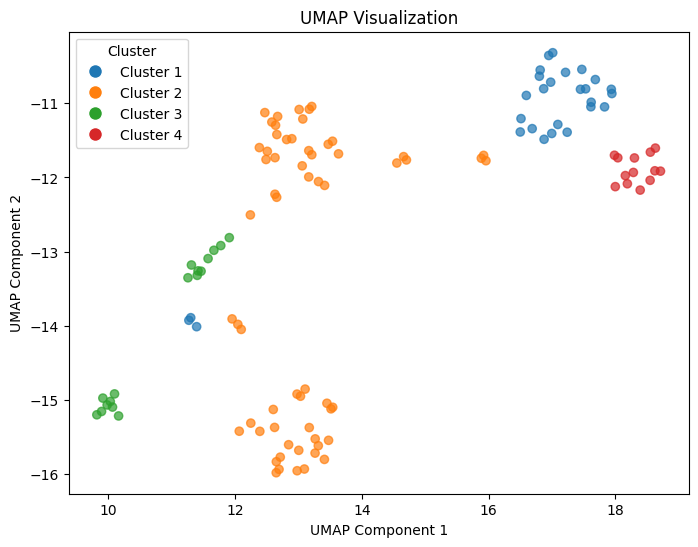

In [60]:
# Optimize UMAP settings
umap_model = umap.UMAP(n_neighbors=40, min_dist=0.05, metric='correlation', random_state=42, n_epochs=2000)
X_umap = umap_model.fit_transform(X)

# Generate better colors
num_clusters = len(set(cluster_labels))
cluster_palette = sns.color_palette("tab10", num_clusters)
cluster_colors = [cluster_palette[label] for label in cluster_labels]

# Plot UMAP
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_colors, alpha=0.7)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("UMAP Visualization")

# Add a legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Cluster {i+1}')
                  for i, color in enumerate(cluster_palette)]
plt.legend(handles=legend_patches, title="Cluster", loc='upper left')

plt.show()


<div style= "text-justified">

In this UMAP,  Cluster 1 (blue) and Cluster 4 (red) appear as compact, isolated groups, suggesting that these samples share strong internal similarities and are transcriptionally distinct from other clusters. Cluster 2 (orange) is more dispersed, implying that the gene expression profiles in this group exhibit more internal variability while still maintaining a coherent structure. Cluster 3 (green), though smaller, remains tightly packed, reinforcing its biological consistency.

</div>
